# cuPauliProp 10-Qubit VQE 예제 (Transverse Field Ising Model)

이 노트북은 NVIDIA `cuPauliProp` API의 강력한 역전파(Backpropagation) 기능을 활용하여 **10 큐비트 시스템에서 VQE(Variational Quantum Eigensolver)**를 구현하는 전체 파이프라인을 다룹니다.

## 1. 문제 정의 (1D TFIM)
1차원 Transverse Field Ising Model (TFIM)의 해밀토니안은 다음과 같이 정의됩니다:
$$ H = - \sum_{i=0}^{N-2} Z_i Z_{i+1} - 0.5 \sum_{i=0}^{N-1} X_i $$

이 시스템의 바닥 상태 에너지를 찾기 위해, `Ry` 회전, `ZZ` 얽힘(Entanglement), `Rx` 회전으로 구성된 **Hardware-efficient Ansatz**를 사용합니다.


In [18]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from cuquantum.pauliprop.experimental import (
    LibraryHandle, PauliExpansion, PauliRotationGate, get_num_packed_integers
)

num_qubits = 50
handle = LibraryHandle()

print(f"시스템 큐비트 수: {num_qubits}")


시스템 큐비트 수: 50


## 2. 해밀토니안(Hamiltonian) 초기화
`PauliExpansion` 객체를 사용하여 GPU 메모리에 TFIM 해밀토니안을 구축합니다.


In [19]:
# 항의 개수: (N-1)개의 ZZ 항 + N개의 X 항
num_terms = (num_qubits - 1) + num_qubits
xz_size = get_num_packed_integers(num_qubits)

# GPU 버퍼 할당
xz_bits = cp.zeros((num_terms, 2 * xz_size), dtype=cp.uint64)
coeffs = cp.zeros((num_terms,), dtype=cp.complex128)

term_idx = 0

# 1. ZZ 항 설정 (J = 1.0)
for i in range(num_qubits - 1):
    xz_bits[term_idx, 1] = (1 << i) | (1 << (i+1)) # Z 비트 활성화
    coeffs[term_idx] = -1.0 + 0.0j
    term_idx += 1

# 2. X 항 설정 (h = 0.5)
for i in range(num_qubits):
    xz_bits[term_idx, 0] = (1 << i) # X 비트 활성화
    coeffs[term_idx] = -0.5 + 0.0j
    term_idx += 1

# 해밀토니안 관측량 생성
H = PauliExpansion(handle, num_qubits, num_terms, xz_bits, coeffs)
print("10-Qubit TFIM 해밀토니안 생성 완료")


10-Qubit TFIM 해밀토니안 생성 완료


## 3. Forward Pass 및 Backward Pass 함수 정의
회로 파라미터(`params`)를 입력받아 **에너지 기대값**과 **파라미터에 대한 기울기(Gradient)**를 동시에 계산하는 함수를 작성합니다.


In [20]:
def compute_energy_and_gradients(H, params):
    # params: 2 * num_qubits 크기의 1D 배열 (Ry 각도, Rx 각도)
    obs_list = [H]
    gate_list = []
    
    # ----------------------------------------------------
    # [1] Forward Pass (관측량 전파: O' = U^dagger O U)
    # ----------------------------------------------------
    
    
    for _ in range(3): # 1개의 반복으로 3개 층 구성
        # Layer 1: Ry 회전 (파라미터 인덱스 0 ~ 9)
        for i in range(num_qubits):
            gate = PauliRotationGate(params[i], "Y", (i,))
            gate_list.append(gate)
            obs_list.append(obs_list[-1].apply_gate(gate, adjoint=True))
            
        # Layer 2: ZZ 얽힘 (고정된 얽힘 게이트, 최적화 대상 아님)
        for i in range(num_qubits - 1):
            gate = PauliRotationGate(np.pi/4, "ZZ", (i, i+1))
            gate_list.append(gate)
            obs_list.append(obs_list[-1].apply_gate(gate, adjoint=True))
            
        # Layer 3: Rx 회전 (파라미터 인덱스 10 ~ 19)
        for i in range(num_qubits):
            gate = PauliRotationGate(params[num_qubits + i], "X", (i,))
            gate_list.append(gate)
            obs_list.append(obs_list[-1].apply_gate(gate, adjoint=True))
            
    # 최종 진화된 관측량
    final_obs = obs_list[-1]
    
    # 에너지 기대값 계산
    trace_sig, trace_exp = final_obs.trace_with_zero_state()
    energy = (trace_sig * (2.0 ** trace_exp)).real
    
    # ----------------------------------------------------
    # [2] Backward Pass (기울기 역전파)
    # ----------------------------------------------------
    
    # 미분 시드 (지수는 미분하지 않음)
    cot_trace_sig = 1.0 * (2.0 ** trace_exp) + 0.0j
    cot_trace_exp = 0.0
    
    cot_evolved = final_obs.trace_with_zero_state_backward_diff(cot_trace_sig, cot_trace_exp)
    
    grads = np.zeros_like(params)
    gate_idx = len(gate_list) - 1 # 가장 마지막 게이트부터 역순으로 탐색
    
    # Rx 계층 역전파
    for i in reversed(range(num_qubits)):
        gate = gate_list[gate_idx]
        input_obs = obs_list[gate_idx] # 게이트가 적용되기 전의 관측량
        
        cot_evolved, param_grad = input_obs.apply_gate_backward_diff(
            gate, cot_evolved.view(), adjoint=True
        )
        grads[num_qubits + i] = param_grad[0].real
        gate_idx -= 1
        
    # ZZ 계층 역전파 (고정 게이트이므로 기울기는 저장하지 않고 통과만 시킴)
    for i in reversed(range(num_qubits - 1)):
        gate = gate_list[gate_idx]
        input_obs = obs_list[gate_idx]
        
        cot_evolved, _ = input_obs.apply_gate_backward_diff(
            gate, cot_evolved.view(), adjoint=True
        )
        gate_idx -= 1
        
    # Ry 계층 역전파
    for i in reversed(range(num_qubits)):
        gate = gate_list[gate_idx]
        input_obs = obs_list[gate_idx]
        
        cot_evolved, param_grad = input_obs.apply_gate_backward_diff(
            gate, cot_evolved.view(), adjoint=True
        )
        grads[i] = param_grad[0].real
        gate_idx -= 1
        
    return energy, grads


## 4. VQE 최적화 루프 (Gradient Descent)
초기 무작위 파라미터에서 시작하여, 에너지가 최소화될 때까지 경사 하강법(Gradient Descent)으로 파라미터를 업데이트합니다.


In [21]:
# 파라미터 초기화
np.random.seed(42)
params = np.random.rand(num_qubits * 2) * np.pi

epochs = 100
learning_rate = 0.05
energy_history = []

print("=== VQE 최적화 시작 ===")
for epoch in range(epochs):
    energy, grads = compute_energy_and_gradients(H, params)
    energy_history.append(energy)
    
    # 경사 하강법 업데이트
    params -= learning_rate * grads
    
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d} | Energy: {energy:.6f}")
        
print("=== 최적화 완료 ===")
print(f"최종 바닥 상태 에너지 근사값: {energy_history[-1]:.6f}")


=== VQE 최적화 시작 ===
Epoch   0 | Energy: -1.929661
Epoch  10 | Energy: -12.742127
Epoch  20 | Energy: -19.457280
Epoch  30 | Energy: -23.705644
Epoch  40 | Energy: -25.302959
Epoch  50 | Energy: -26.861297
Epoch  60 | Energy: -28.496846
Epoch  70 | Energy: -29.677036
Epoch  80 | Energy: -30.403295
Epoch  90 | Energy: -31.169067
Epoch  99 | Energy: -31.895716
=== 최적화 완료 ===
최종 바닥 상태 에너지 근사값: -31.895716


## 5. 학습 곡선 시각화
VQE 최적화 과정에서 에너지가 수렴하는 모습을 확인합니다.


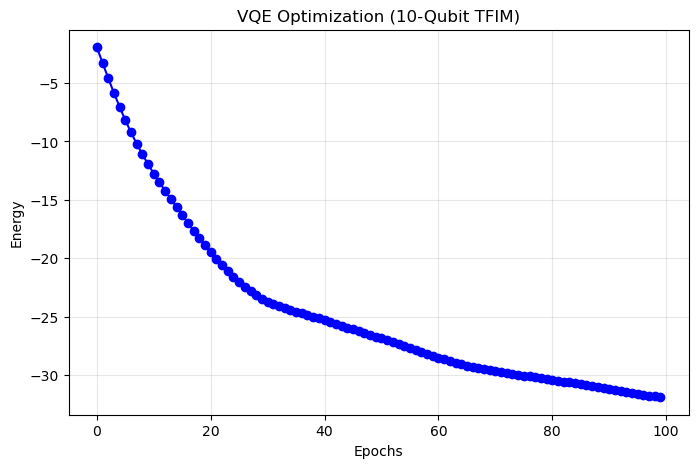

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(energy_history, marker='o', linestyle='-', color='b')
plt.title("VQE Optimization (10-Qubit TFIM)")
plt.xlabel("Epochs")
plt.ylabel("Energy")
plt.grid(True, alpha=0.3)
plt.show()
